In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
block=pd.read_csv(r"C:\Users\stama\Υπολογιστής\Blockchain(On-chain data)\blockchain_risk_data.csv")

In [3]:
# 1. Basic statistics on transaction values
print("Data Description:")
print(block['Value_ETH'].describe())

# 2.Feature Engineering: Find "Whale" transactions (high risk/value)
whales = block[block['Value_ETH'] > 1.0]
print(f"\nthey were found {len(whales)} transactions over 1 ETH.")

# 3. The 5 most active Wallets (Possible bots or exchanges)
print("\nTop 5 Addresses (Senders):")
print(block['From'].value_counts().head(5))

Data Description:
count    819.000000
mean       0.609730
std       14.658303
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000201
max      417.822553
Name: Value_ETH, dtype: float64

they were found 12 transactions over 1 ETH.

Top 5 Addresses (Senders):
0x974CaA59e49682CdA0AD2bbe82983419A2ECC400    105
0x787B8840100d9BaAdD7463f4a73b5BA73B00C6cA     10
0xB8001C3eC9AA1985f6c747E25c28324E4A361ec1      9
0x1AB4973a48dc892Cd9971ECE8e01DcC7688f8F23      8
0x264bd8291fAE1D75DB2c5F573b07faA6715997B5      6
Name: From, dtype: int64


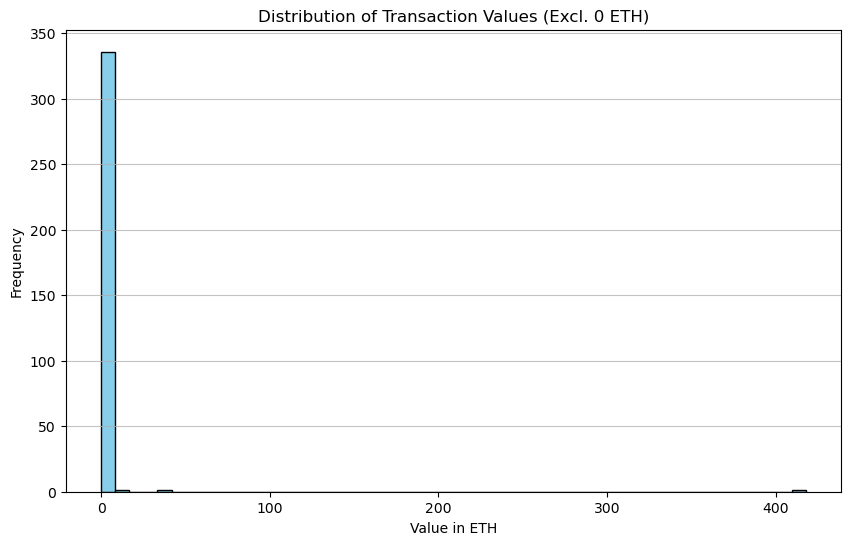

In [4]:
# We filter out very small transactions to clearly see the distribution
filtered_data = block[block['Value_ETH'] > 0]

plt.figure(figsize=(10, 6))
plt.hist(filtered_data['Value_ETH'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Transaction Values (Excl. 0 ETH)')
plt.xlabel('Value in ETH')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [5]:
# We define the limits for the Risk Category
def identify_risk(value):
    if value == 0:
        return 'Low (Contract Call)'
    elif value < 0.5:
        return 'Medium'
    elif value < 5:
        return 'High'
    else:
        return 'Critical (Whale)'

# Implementing Segmentation
block['Risk_Level'] = block['Value_ETH'].apply(identify_risk)

# View the Segmentation results
print("Risk Segmentation Analysis:")
print(block['Risk_Level'].value_counts())

Risk Segmentation Analysis:
Low (Contract Call)    480
Medium                 321
High                    14
Critical (Whale)         4
Name: Risk_Level, dtype: int64
